In [40]:
import numpy as np
import pandas as pd
from scipy.stats import norm

import numpy as np

mu = -3.67/100
x0 = 75.72

keys = [
    "Dec-23","Jan-24","Feb-24","Mar-24","Apr-24","May-24","Jun-24","Jul-24","Aug-24","Sep-24","Oct-24","Nov-24","Dec-24",
    "Jan-25","Feb-25","Mar-25","Apr-25","May-25","Jun-25","Jul-25","Aug-25","Sep-25","Oct-25","Nov-25","Dec-25"
]

values = x0 * np.exp(mu * np.arange(len(keys))) 
futures_curve = {k: round(v, 3) for k, v in zip(keys, values)}

pricing_date = pd.Timestamp("2023-12-08")
S0 = x0
sigma = 23/100

def maturity_date(label):
    d0 = pd.to_datetime(label, format="%b-%y")  # 1er jour du mois
    return d0 + pd.offsets.MonthEnd(0)

def build_strip_df(curve, pricing_date, start="Jan-24", end="Dec-25"):
    s = pd.Series(curve).rename("F0")
    idx = pd.to_datetime(s.index, format="%b-%y")
    df = pd.DataFrame({"label": s.index, "F0": s.values}, index=idx).sort_index()

    start_dt = pd.to_datetime(start, format="%b-%y")
    end_dt = pd.to_datetime(end, format="%b-%y")
    df = df.loc[(df.index >= start_dt) & (df.index <= end_dt)].copy()

    df["maturity"] = [maturity_date(lbl) for lbl in df["label"]]
    df["T"] = (df["maturity"] - pricing_date).dt.days / 365.0
    return df

def implied_carry_b(df, S0):
    return np.log(df["F0"] / S0) / df["T"]

def mc_strip_call_payoff_spot(df, S0, sigma, mu, K, r, n_sims=200000, seed=42):
    rng = np.random.default_rng(seed)
    T = df["T"].to_numpy()
    K = np.asarray(K)
    m = len(df)

    Z_mat = rng.standard_normal((n_sims, m))
    drift = (mu - 0.5 * sigma**2) * T
    volterm = sigma * np.sqrt(T)

    ST = S0 * np.exp(drift[None, :] + volterm[None, :] * Z_mat)
    payoff_mat = np.maximum(ST - K[None, :], 0.0)        

    disc = np.exp(-r * T)                                 
    payoff_pv_mat = payoff_mat * disc[None, :]            

    strip_payoff_pv = payoff_pv_mat.sum(axis=1)            

    out = df.copy()
    out["K"] = K
    out["E_payoff_at_T"] = payoff_mat.mean(axis=0)         
    out["E_payoff_PV"]   = payoff_pv_mat.mean(axis=0)     

    return out, strip_payoff_pv, strip_payoff_pv.mean()

df = build_strip_df(futures_curve, pricing_date, start="Jan-24", end="Dec-25")
df["b_implied"] = implied_carry_b(df, S0)

K = df["F0"].to_numpy()


r = 5/100
res, strip_payoffs_pv, E_strip_pv = mc_strip_call_payoff_spot(df, S0, sigma, mu, K, r, n_sims=200000, seed=7)

print(res[["label", "F0", "T", "b_implied", "E_payoff_at_T", "E_payoff_PV"]])
print("PV moyen du strip =", E_strip_pv)


             label      F0         T  b_implied  E_payoff_at_T  E_payoff_PV
2024-01-01  Jan-24  72.991  0.147945  -0.248107       3.938842     3.909813
2024-02-01  Feb-24  70.361  0.227397  -0.322797       6.099630     6.030671
2024-03-01  Mar-24  67.826  0.312329  -0.352503       8.162607     8.036126
2024-04-01  Apr-24  65.382  0.394521  -0.372085      10.201247    10.001989
2024-05-01  May-24  63.026  0.479452  -0.382718      12.218169    11.928750
2024-06-01  Jun-24  60.755  0.561644  -0.392051      14.155956    13.763956
2024-07-01  Jul-24  58.565  0.646575  -0.397332      16.002918    15.493837
2024-08-01  Aug-24  56.455  0.731507  -0.401361      17.792879    17.153856
2024-09-01  Sep-24  54.421  0.813699  -0.405915      19.510726    18.732865
2024-10-01  Oct-24  52.460  0.898630  -0.408390      21.227351    20.294684
2024-11-01  Nov-24  50.569  0.980822  -0.411597      22.785806    21.695322
2024-12-01  Dec-24  48.747  1.065753  -0.413228      24.273111    23.013512
2025-01-01  

In [41]:
def simulate_ST(df, S0, sigma, mu, n_sims=200000, seed=7):
    rng = np.random.default_rng(seed)
    T = df["T"].to_numpy()
    m = len(df)
    
    Z = rng.standard_normal((n_sims, m))
    drift = (mu - 0.5 * sigma**2) * T
    volterm = sigma * np.sqrt(T)

    ST = S0 * np.exp(drift[None, :] + volterm[None, :] * Z)
    return ST

n_sims = 200000
seed = 7
ST = simulate_ST(df, S0=S0, sigma=sigma, mu=mu, n_sims=n_sims, seed=seed)

labels = df["label"].to_numpy()
F0 = df["F0"].to_numpy()  

q_ST = np.quantile(ST, [0.05, 0.50, 0.95], axis=0)
df_sans_couverture = pd.DataFrame({
    "label": labels,
    "E[ST]": ST.mean(axis=0),
    "ST_q05": q_ST[0],
    "ST_q50": q_ST[1],
    "ST_q95": q_ST[2],
})

print("=== Sans couverture ===")
print(df_sans_couverture)


=== Sans couverture ===
     label      E[ST]     ST_q05     ST_q50      ST_q95
0   Jan-24  75.307414  64.821088  75.031294   86.738275
1   Feb-24  75.098993  62.304462  74.667138   89.399699
2   Mar-24  74.814612  60.019040  74.198799   91.643088
3   Apr-24  74.590243  58.213659  73.808131   93.691100
4   May-24  74.402300  56.515882  73.486316   95.486927
5   Jun-24  74.219281  55.133222  73.128634   97.056764
6   Jul-24  73.967965  53.666585  72.695668   98.643501
7   Aug-24  73.742050  52.406916  72.367841   99.952671
8   Sep-24  73.495737  51.085343  71.902721  101.350372
9   Oct-24  73.318117  49.967874  71.634585  102.590570
10  Nov-24  73.051315  49.024071  71.179709  103.492941
11  Dec-24  72.759972  47.995086  70.718925  104.461696
12  Jan-25  72.577397  46.965851  70.403950  105.671879
13  Feb-25  72.412831  46.040473  70.110026  106.651172
14  Mar-25  72.192360  45.099854  69.717923  107.823266
15  Apr-25  71.925836  44.431782  69.249176  108.486656
16  May-25  71.723448  4

    label      E[ST]       K  E_payoff_PV  S_real  StripCall_expected  \
0  Jan-24  75.307414  72.991     3.909813   77.67           76.900813   
1  Feb-24  75.098993  70.361     6.030671   80.55           76.391671   
2  Mar-24  74.814612  67.826     8.036126   83.55           75.862126   
3  Apr-24  74.590243  65.382    10.001989   88.01           75.383989   
4  May-24  74.402300  63.026    11.928750   81.45           74.954750   

   StripCall_realized  Real_cum  StripCall_expected_cum  \
0           76.900813     77.67               76.900813   
1           76.391671    158.22              153.292484   
2           75.862126    241.77              229.154609   
3           75.383989    329.78              304.538599   
4           74.954750    411.23              379.493349   

   StripCall_realized_cum  
0               76.900813  
1              153.292484  
2              229.154609  
3              304.538599  
4              379.493349  

Cumul final réel = 1753.9300000000003

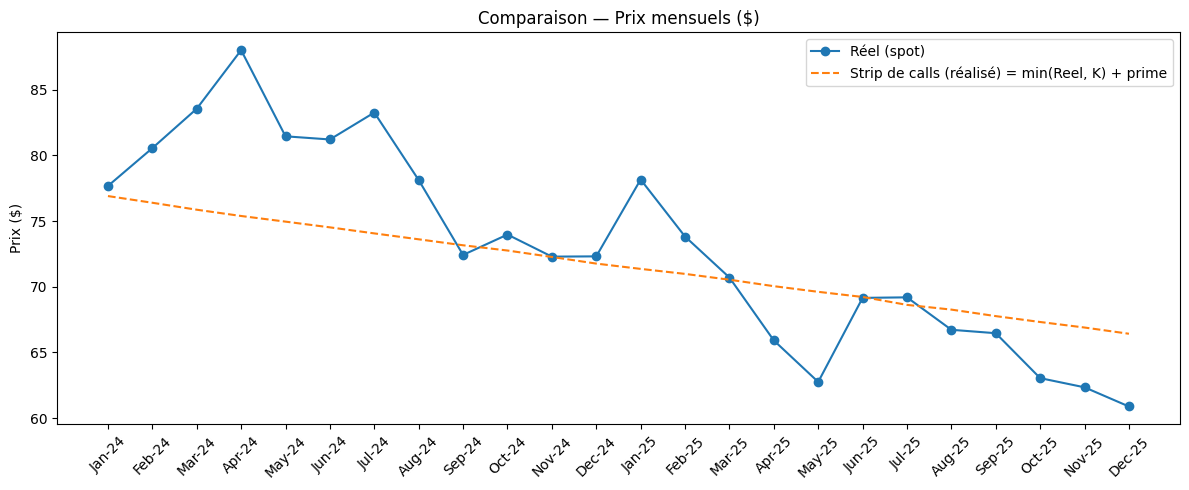

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

real_costs = {
    "Dec-23": 75.72,
    "Jan-24": 77.67,
    "Feb-24": 80.55,
    "Mar-24": 83.55,
    "Apr-24": 88.01,
    "May-24": 81.45,
    "Jun-24": 81.21,
    "Jul-24": 83.26,
    "Aug-24": 78.12,
    "Sep-24": 72.42,
    "Oct-24": 73.97,
    "Nov-24": 72.29,
    "Dec-24": 72.31,
    "Jan-25": 78.16,
    "Feb-25": 73.82,
    "Mar-25": 70.70,
    "Apr-25": 65.91,
    "May-25": 62.75,
    "Jun-25": 69.15,
    "Jul-25": 69.19,
    "Aug-25": 66.72,
    "Sep-25": 66.46,
    "Oct-25": 63.04,
    "Nov-25": 62.34,
    "Dec-25": 60.88
}



df_real = pd.DataFrame({
    "label": df_sans_couverture["label"].values,
    "S_real": [real_costs[lbl] for lbl in df_sans_couverture["label"].values]
})

df_comp = (
    df_sans_couverture[["label", "E[ST]"]]
    .merge(res[["label", "K", "E_payoff_PV"]], on="label", how="left")
    .merge(df_real, on="label", how="left")
)

df_comp["StripCall_expected"] = np.minimum(df_comp["E[ST]"], df_comp["K"]) + df_comp["E_payoff_PV"]
df_comp["StripCall_realized"] = np.minimum(df_comp["S_real"], df_comp["K"]) + df_comp["E_payoff_PV"]

df_comp["Real_cum"] = df_comp["S_real"].cumsum()
df_comp["StripCall_expected_cum"] = df_comp["StripCall_expected"].cumsum()
df_comp["StripCall_realized_cum"] = df_comp["StripCall_realized"].cumsum()

print(df_comp.head())
print("\nCumul final réel =", df_comp["Real_cum"].iloc[-1])
print("Cumul final strip (réalisé) =", df_comp["StripCall_realized_cum"].iloc[-1])
print("Cumul final strip (attendu) =", df_comp["StripCall_expected_cum"].iloc[-1])

plt.figure(figsize=(12,5))

plt.plot(df_comp["label"], df_comp["S_real"], marker="o", label="Réel (spot)")
#plt.plot(df_comp["label"], df_comp["StripCall_expected"], linestyle="--",
         #label="Strip de calls (attendu) = min(E[ST], K) + prime")
plt.plot(df_comp["label"], df_comp["StripCall_realized"], linestyle="dashed",
         label="Strip de calls (réalisé) = min(Reel, K) + prime")

plt.title("Comparaison — Prix mensuels ($)")
plt.ylabel("Prix ($)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

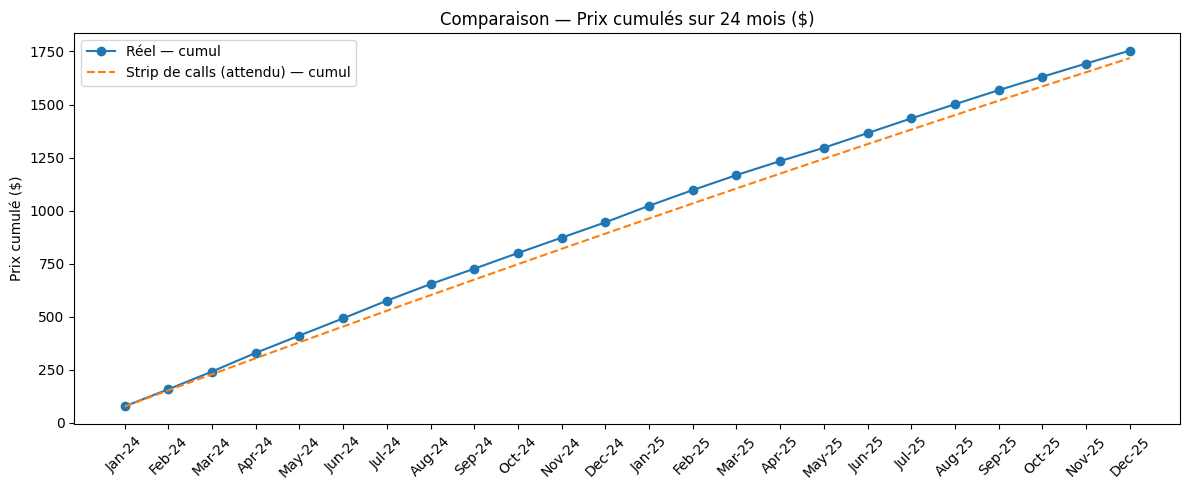

In [43]:
plt.figure(figsize=(12,5))
plt.plot(df_comp["label"], df_comp["Real_cum"], marker="o", label="Réel — cumul")
plt.plot(df_comp["label"], df_comp["StripCall_realized_cum"], linestyle="--",
         label="Strip de calls (attendu) — cumul")

plt.title("Comparaison — Prix cumulés sur 24 mois ($)")
plt.ylabel("Prix cumulé ($)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


In [51]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

Q_month = 1692460

x = pd.to_datetime(df_comp["label"], format="%b-%y", errors="coerce")
use_dt = not x.isna().any()
if not use_dt:
    x = df_comp["label"]  # fallback to raw labels

real  = df_comp["Real_cum"].astype(float) * Q_month
calls = df_comp["StripCall_realized_cum"].astype(float) * Q_month
diff  = calls - real

fig = make_subplots(
    rows=2, cols=1,
    shared_xaxes=True,
    vertical_spacing=0.12,
    row_heights=[0.70, 0.30],
    subplot_titles=("Coût cumulé (Réel vs Strip de calls)", "Différence (Calls − Réel)")
)

x_hover = "%{x|%b-%y}" if use_dt else "%{x}"

fig.add_trace(
    go.Scatter(
        x=x, y=real,
        mode="lines+markers",
        name="Réel — coût cumulé",
        hovertemplate=f"{x_hover}<br>Réel: %{{y:,.0f}} $<extra></extra>"
    ),
    row=1, col=1
)

fig.add_trace(
    go.Scatter(
        x=x, y=calls,
        mode="lines+markers",
        line=dict(dash="dash"),
        name="Strip de calls — coût cumulé",
        hovertemplate=f"{x_hover}<br>Calls: %{{y:,.0f}} $<extra></extra>"
    ),
    row=1, col=1
)

fig.add_trace(
    go.Scatter(
        x=x, y=diff,
        mode="lines+markers",
        name="Calls − Réel",
        hovertemplate=f"{x_hover}<br>Diff: %{{y:,.0f}} $<extra></extra>"
    ),
    row=2, col=1
)

fig.update_layout(
    title=f"Comparaison — Coût cumulé sur 24 mois (Q mensuelle = {Q_month:,.2f})",
    hovermode="x unified",
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="left", x=0),
    height=650,
    margin=dict(l=60, r=30, t=90, b=60),
)

fig.update_yaxes(title_text="Coût cumulé ($)", row=1, col=1)
fig.update_yaxes(title_text="Diff ($)", row=2, col=1, zeroline=True)

if use_dt:
    fig.update_xaxes(rangeslider_visible=True, row=2, col=1)

fig.show()
